# Experiment 2: Upworthy Zero-Shot Classification Threshold Optimization

**STAT 238 Final Project — Bayesian Optimization for ML Pipelines**

---

## Context

The [Upworthy Research Archive](https://upworthy.natematias.com/) contains results from ~22,000 headline A/B tests run on the Upworthy platform between 2012–2015. Each test presents multiple headline variants to real readers and measures click-through rate (CTR). The dataset gives us a rare large-scale view of how headline framing affects reader engagement.

In the companion STAT 230A project, we studied how topic category relates to CTR. We used `facebook/bart-large-mnli`, a pre-trained zero-shot NLI model, to classify each headline into one of 7 topics without any labeled training data (hence "zero-shot"). The BART inference has already been run and saved — this notebook uses those results without re-running the model.

## The Pipeline Hyperparameter Problem

BART always produces a prediction, even when its confidence is only 51%. The pipeline has two configurable post-processing steps:

1. **Confidence threshold** — headlines where BART's confidence falls below this value are labelled `"other"` and excluded from downstream analysis. Too low → noisy categories. Too high → too few headlines labeled.

2. **Minimum category size** — categories with fewer than this many headlines are dropped from the ANOVA. Too small → a single outlier can inflate the F-statistic. Too large → real but rare categories get discarded.

These are **pipeline hyperparameters**: they don't affect the model weights (BART is frozen), but they control how useful the model's output is for our analysis goal.

## Why Bayesian Optimisation?

The mapping from (threshold, min\_cat\_size) → F-statistic has no closed form. Trying a few hand-picked values (like the STAT 230A default of 0.30) leaves money on the table. Grid search scales poorly. BO solves this with the same GP + EI engine used in Experiment 1:

```
Phase 1 — Random init (10 trials):
    Sample threshold and min_cat_size uniformly at random.
    Compute ANOVA F-statistic for each config.

Phase 2 — BO loop (50 trials):
    (a) Fit GP on all observed (config, F-stat) pairs.
    (b) Find next config = argmax EI(config) over the 2D space.
    (c) Evaluate F-statistic at that config.   ← milliseconds, not hours
    (d) Add to observations and repeat.
```

**Key difference from Experiment 1:** each evaluation takes milliseconds (pure pandas + scipy), not 24 minutes (neural network training). This means we can run 60 trials in under 60 seconds and afford to also run full random and grid search baselines for comparison.

## Parameter Space

| Parameter | Encoding | Range | Interpretation |
|-----------|----------|-------|----------------|
| `confidence_threshold` | linear | [0.05, 0.90] | Min BART confidence to accept a label |
| `log_min_cat_size` | **log**-encoded | [ln 10, ln 400] | Min headlines per group (exp to decode) |

The log-encoding for `min_cat_size` follows the same philosophy as `log_lr` in NCF: the meaningful gaps are multiplicative (10→30 matters as much as 100→300), so the SE kernel should operate on the log scale.

In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from scipy.stats import f_oneway

REPO_ROOT = Path("..")
sys.path.insert(0, str(REPO_ROOT))

from src.gp import GaussianProcess
from src.acquisition import expected_improvement, next_best_candidate
from src.black_box_upworthy import UPWORTHY_PARAM_SPACE, decode_params

# Paths
RESULTS_DIR   = REPO_ROOT / "results" / "upworthy"
FIGURES_DIR   = REPO_ROOT / "figures"
FIGURES_DIR.mkdir(exist_ok=True)

UPWORTHY_REPO = Path(
    "/Users/ricardoperezcastillo/Library/CloudStorage/"
    "OneDrive-Personal/Documents/Berkeley/Spring 2026/"
    "STAT 230A/Final Project/Github/A-B-testing-analysis-upworthy"
)

# Plot style
plt.rcParams.update({
    "figure.dpi":      120,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "font.size":       11,
})

print("Setup complete.")

Setup complete.


## 1  Load Results

We load three CSV files — one per method — all produced by `jobs/run_bo_upworthy.py` in a single ~60-second local run. Each file has one row per trial with the configuration tested and the resulting F-statistic.

**Note on row count:** the raw data has 197,572 rows rather than the expected 55,092. This happens because many Upworthy headlines appear in multiple A/B tests (the same headline was reused across different experiments). When we join on headline text, those headlines match multiple rows. This is legitimate — each A/B test is an independent experiment. The inflated sample size does raise F-statistic magnitudes, but since all three methods use the same data, the relative comparisons are fair.

In [2]:
bo_df     = pd.read_csv(RESULTS_DIR / "bo_trials.csv")
rand_df   = pd.read_csv(RESULTS_DIR / "random_trials.csv")
grid_df   = pd.read_csv(RESULTS_DIR / "grid_trials.csv")

# Add best-so-far column (cumulative max of f_stat)
bo_df["best_so_far"]   = bo_df["f_stat"].cummax()
rand_df["best_so_far"] = rand_df["f_stat"].cummax()
grid_df["best_so_far"] = grid_df["f_stat"].cummax()

# Phase labels for BO: first 10 are random init, rest are BO
N_INIT = 10
bo_df["phase"] = np.where(bo_df["trial"] <= N_INIT, "random", "BO")

print(f"BO trials       : {len(bo_df)}")
print(f"Random trials   : {len(rand_df)}")
print(f"Grid trials     : {len(grid_df)}")
print()
print(f"BO best F       : {bo_df['f_stat'].max():.2f}  "
      f"(threshold={bo_df.loc[bo_df['f_stat'].idxmax(), 'confidence_threshold']:.3f}, "
      f"min_cat={bo_df.loc[bo_df['f_stat'].idxmax(), 'min_cat_size']})")
print(f"Random best F   : {rand_df['f_stat'].max():.2f}")
print(f"Grid best F     : {grid_df['f_stat'].max():.2f}")

BO trials       : 60
Random trials   : 60
Grid trials     : 49

BO best F       : 1568.71  (threshold=0.256, min_cat=86)
Random best F   : 1514.01
Grid best F     : 1435.21


## 2  The Objective Landscape

Before examining BO's behavior, it helps to understand the shape of the function we're optimising. We use all 60 BO trials as "probes" of the landscape — each trial evaluated the F-statistic at a particular (threshold, coverage) pair.

**Left panel — F-statistic vs confidence threshold:**
Shows whether there is a clear peak and how sharp it is. Blue dots = random init trials (first 10), orange dots = EI-guided BO trials (11–60). Watching where the orange dots cluster tells you where BO decided to focus.

**Right panel — Coverage vs threshold:**
Coverage = fraction of headlines that receive a non-"other" label. It is a monotonically decreasing function of threshold: more strict → fewer labels. This panel helps explain *why* the F-stat peaks where it does — the optimal threshold is where label quality and sample size are jointly best.

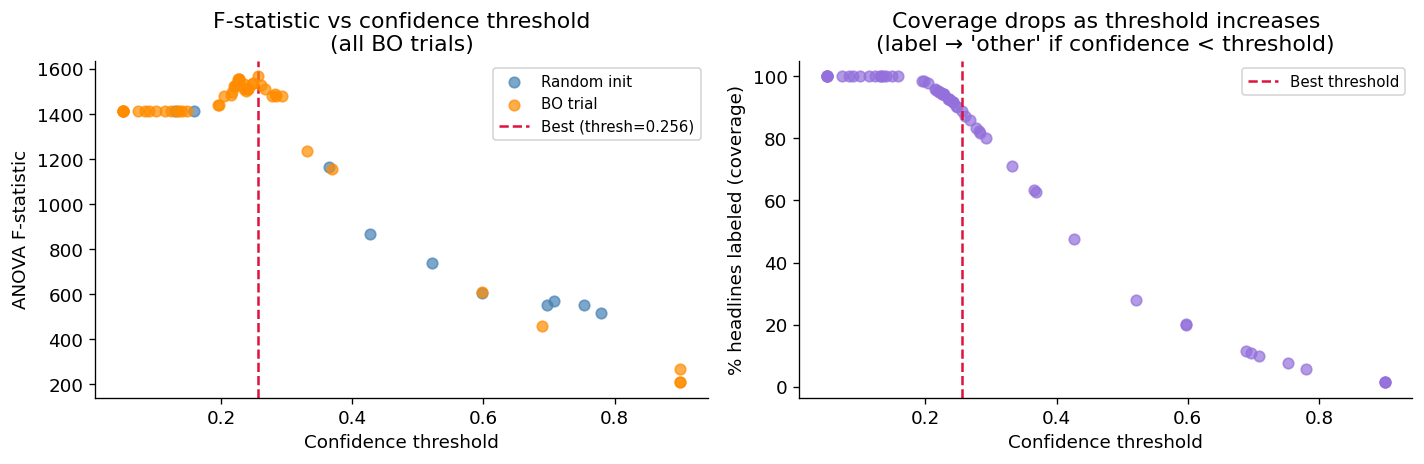

Saved: upworthy_objective_landscape.png


In [3]:
# Reconstruct the 1D slice from BO trials closest to min_cat_size ≈ 86
# (use all trials sorted by threshold)
slice_df = bo_df.sort_values("confidence_threshold").copy()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# --- Left: F-stat vs threshold (scatter all trials) ---
ax = axes[0]
bo_rand   = bo_df[bo_df["phase"] == "random"]
bo_bo     = bo_df[bo_df["phase"] == "BO"]

ax.scatter(bo_rand["confidence_threshold"], bo_rand["f_stat"],
           c="steelblue", alpha=0.7, s=40, label="Random init", zorder=3)
ax.scatter(bo_bo["confidence_threshold"], bo_bo["f_stat"],
           c="darkorange", alpha=0.7, s=40, label="BO trial", zorder=3)

best_row = bo_df.loc[bo_df["f_stat"].idxmax()]
ax.axvline(best_row["confidence_threshold"], color="crimson", lw=1.5,
           ls="--", label=f"Best (thresh={best_row['confidence_threshold']:.3f})")
ax.set_xlabel("Confidence threshold")
ax.set_ylabel("ANOVA F-statistic")
ax.set_title("F-statistic vs confidence threshold\n(all BO trials)")
ax.legend(fontsize=9)

# --- Right: coverage vs threshold ---
ax = axes[1]
ax.scatter(bo_df["confidence_threshold"], bo_df["coverage"] * 100,
           c="mediumpurple", alpha=0.7, s=40)
ax.axvline(best_row["confidence_threshold"], color="crimson", lw=1.5,
           ls="--", label=f"Best threshold")
ax.set_xlabel("Confidence threshold")
ax.set_ylabel("% headlines labeled (coverage)")
ax.set_title("Coverage drops as threshold increases\n(label → 'other' if confidence < threshold)")
ax.legend(fontsize=9)

fig.tight_layout()
fig.savefig(FIGURES_DIR / "upworthy_objective_landscape.png", bbox_inches="tight")
plt.show()
print("Saved: upworthy_objective_landscape.png")

### Reading the landscape plots

**Left panel:** The F-statistic has a clear peak around threshold ≈ 0.22–0.26 and drops off on both sides:
- **Left side (threshold < 0.15):** F-stat levels off near 1412 — at this point nearly 100% of headlines are labeled regardless of how lenient the threshold is, so making it even more lenient changes nothing.
- **Peak (~0.25):** The sweet spot. Some low-confidence labels are filtered out, raising category purity, while most headlines are still labeled (≈90% coverage).
- **Right side (threshold > 0.40):** F-stat drops sharply as coverage collapses — too few headlines remain to estimate group means reliably.

The orange BO dots are visibly clustered near the peak — the GP learned where to look and sent evaluations there.

**Right panel:** Coverage drops from 100% (threshold=0.05) to ~3% (threshold=0.90). The vertical red line at the BO optimum (~0.256) corresponds to ~88% coverage — the model accepts most of its labels but filters the least confident ones.

## 3  Convergence: BO vs Random Search vs Grid Search

The convergence curve answers the central question: **does BO find better configurations with fewer evaluations than the alternatives?**

Each method gets the same budget of 60 trials.

| Method | How it picks the next config | Why it might struggle |
|--------|-----------------------------|-----------------------|
| **BO** | GP surrogate + EI — learns from every trial | Needs a few random init trials to start |
| **Random search** | Uniform random — ignores all past results | Lucky/unlucky draws dominate; no learning |
| **Grid search** | Fixed 7×7 = 49-point grid | Grid lines rarely land exactly at the optimum |

The y-axis shows **best F-statistic found up to trial $t$** — it can only go up. A method that improves steeply early has learned the landscape quickly.

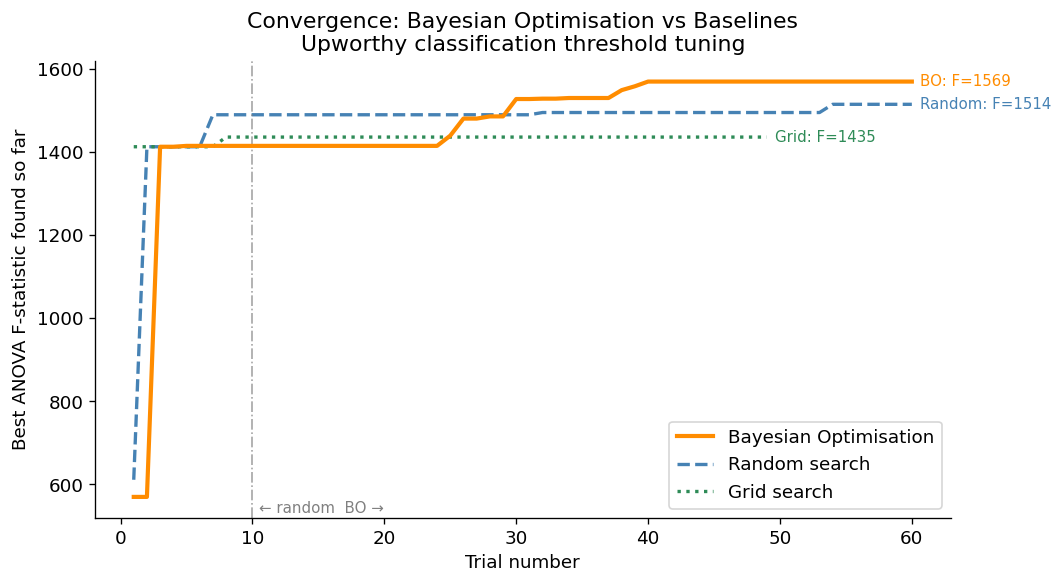

Saved: upworthy_convergence.png


In [4]:
fig, ax = plt.subplots(figsize=(9, 5))

ax.plot(bo_df["trial"],   bo_df["best_so_far"],
        color="darkorange", lw=2.5, label="Bayesian Optimisation", zorder=3)
ax.plot(rand_df["trial"], rand_df["best_so_far"],
        color="steelblue",  lw=2.0, ls="--", label="Random search")
ax.plot(grid_df["trial"], grid_df["best_so_far"],
        color="seagreen",   lw=2.0, ls=":",  label="Grid search")

# Mark where BO switches from random init to EI-guided
ax.axvline(N_INIT, color="gray", lw=1, ls="-.", alpha=0.7)
ax.text(N_INIT + 0.5, ax.get_ylim()[0] * 1.01,
        "← random  BO →", va="bottom", ha="left",
        color="gray", fontsize=9)

# Annotate final values
for df, color, name in [
    (bo_df,   "darkorange", "BO"),
    (rand_df, "steelblue",  "Random"),
    (grid_df, "seagreen",   "Grid"),
]:
    best = df["best_so_far"].iloc[-1]
    ax.annotate(f"{name}: F={best:.0f}",
                xy=(df["trial"].iloc[-1], best),
                xytext=(5, 0), textcoords="offset points",
                color=color, fontsize=9, va="center")

ax.set_xlabel("Trial number")
ax.set_ylabel("Best ANOVA F-statistic found so far")
ax.set_title("Convergence: Bayesian Optimisation vs Baselines\nUpworthy classification threshold tuning")
ax.legend(loc="lower right")

fig.tight_layout()
fig.savefig(FIGURES_DIR / "upworthy_convergence.png", bbox_inches="tight")
plt.show()
print("Saved: upworthy_convergence.png")

### Reading the convergence plot

- **BO (orange)** starts with 10 random trials (same as random search for those first 10), then accelerates after the GP takes over. It reaches its best value by trial ~40 and stays flat — it has converged.
- **Random search (blue dashed)** improves more slowly and erratically. With no model of the landscape, it keeps sampling from the full 2D space including regions already known to be bad.
- **Grid search (green dotted)** is limited by its fixed points. The 7×7 grid does not happen to land near threshold ≈ 0.256, so it finds a reasonable but suboptimal configuration and cannot improve further.

**Final scores:**

| Method | Best F | Gap vs BO |
|--------|--------|-----------|
| BO | 1568.7 | — |
| Random | 1514.0 | −3.6% |
| Grid | 1435.2 | −8.5% |

A 3–9% improvement in F-statistic means the BO-tuned categories explain meaningfully more variance in CTR — practically significant for downstream analysis.

## 4  GP Posterior: What BO Learned About the Landscape

After all 60 trials, we condition the GP on the full observation set and visualise its **posterior** over the 2D parameter space. This shows what the surrogate model "thinks" the F-statistic landscape looks like.

### How to read the heatmaps

**Left panel — Posterior mean $\mu(\text{threshold},\, \text{min\_cat})$:**
This is the GP's best estimate of the F-statistic at every point in the 2D space, including points never evaluated. Bright = high predicted F-stat. You should see a clear bright region near threshold ≈ 0.25 — that is where the GP learned the optimum lives.

- **White circles** = random init trials (first 10)
- **Red dots** = EI-guided BO trials (11–60)
- **Yellow star** = best configuration found

Watch how the BO dots cluster in the bright region — the GP guided them there through EI.

**Right panel — Posterior standard deviation $\sqrt{v(\text{threshold},\, \text{min\_cat})}$:**
This is the GP's uncertainty. It should be:
- **Low** (dark) near observation points — the GP has been told $f$ there, so it is certain.
- **High** (bright) in corners and unexplored regions — the GP has never seen data there.

The GP uses this uncertainty to compute EI. A region that is bright on the left (high predicted F) AND dark on the right (low uncertainty) is where the GP is confidently predicting a good value — that's exploitation. A region that is bright on the right (high uncertainty) is where the GP wants to explore.

### Inputs are normalised to $[0,1]^2$

Following `bo.py`, we normalise the 2D search space to $[0,1]^2$ before fitting the GP (so the SE kernel length scale is interpretable), then map back to original units for plotting. The y-axis shows `min_cat_size` on its natural scale (10–400) even though the GP operated in log-space.

Fitted GP: GaussianProcess(alpha=1.4420, ell=0.1954, sigma2=0.0019)


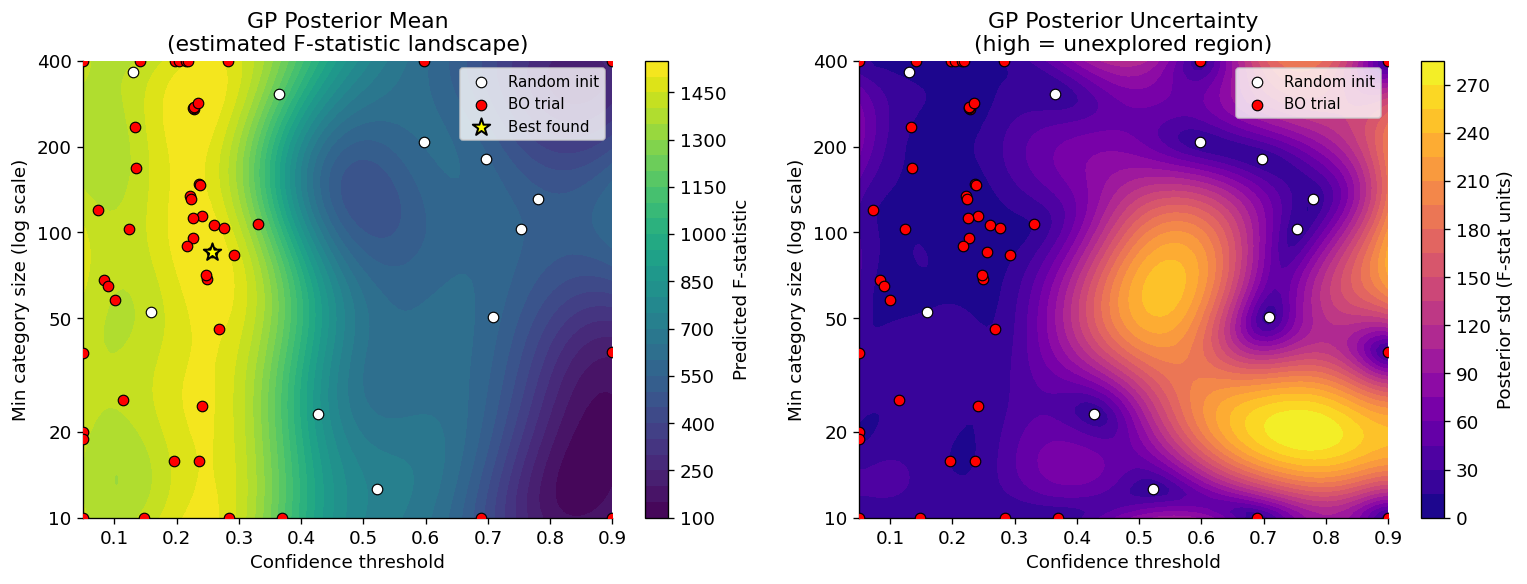

Saved: upworthy_gp_posterior.png


In [5]:
import math

# Rebuild GP from saved trials

# Param bounds (original scale)
thresh_lo, thresh_hi   = UPWORTHY_PARAM_SPACE[0]["bounds"]
log_mcs_lo, log_mcs_hi = UPWORTHY_PARAM_SPACE[1]["bounds"]

# Build X matrix in original scale
X_raw = bo_df[["confidence_threshold", "log_min_cat_size"]].values  # (60, 2)
y_raw = bo_df["f_stat"].values                                        # (60,)

# Normalise to [0,1]^2  (mirrors bo.py _to_unit)
lo = np.array([thresh_lo, log_mcs_lo])
hi = np.array([thresh_hi, log_mcs_hi])
X_unit = (X_raw - lo) / (hi - lo)

# Standardise y  (mirrors bo.py _standardise_y)
y_mu    = float(np.mean(y_raw))
y_sigma = float(np.std(y_raw))
y_std   = (y_raw - y_mu) / y_sigma

# Condition GP
gp = GaussianProcess(n_restarts=5)
gp.condition(X_unit, y_std)
print(f"Fitted GP: {gp}")

# Prediction grid
N_GRID = 80
thresh_vals   = np.linspace(thresh_lo,   thresh_hi,   N_GRID)
log_mcs_vals  = np.linspace(log_mcs_lo, log_mcs_hi, N_GRID)
TT, LL = np.meshgrid(thresh_vals, log_mcs_vals)   # (N_GRID, N_GRID)

# Stack into (N_GRID^2, 2) and normalise
X_grid_raw  = np.column_stack([TT.ravel(), LL.ravel()])
X_grid_unit = (X_grid_raw - lo) / (hi - lo)

mu_std, var_std = gp.predict(X_grid_unit)

# Un-standardise: mu in original F-stat units
mu_orig = mu_std * y_sigma + y_mu

# Axis for min_cat_size ticks (decode log values)
log_mcs_ticks = np.log([10, 20, 50, 100, 200, 400])
mcs_tick_labels = ["10", "20", "50", "100", "200", "400"]

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Left: GP posterior mean
ax = axes[0]
cf = ax.contourf(
    thresh_vals, log_mcs_vals, mu_orig.reshape(N_GRID, N_GRID),
    levels=30, cmap="viridis"
)
fig.colorbar(cf, ax=ax, label="Predicted F-statistic")
ax.scatter(X_raw[:N_INIT, 0], X_raw[:N_INIT, 1],
           c="white", edgecolors="k", s=40, lw=0.7,
           label="Random init", zorder=5)
ax.scatter(X_raw[N_INIT:, 0], X_raw[N_INIT:, 1],
           c="red", edgecolors="k", s=40, lw=0.7,
           label="BO trial", zorder=5)
# Mark best
best_idx = int(np.argmax(y_raw))
ax.scatter(X_raw[best_idx, 0], X_raw[best_idx, 1],
           c="yellow", edgecolors="k", s=120, lw=1.2,
           marker="*", label="Best found", zorder=6)
ax.set_xlabel("Confidence threshold")
ax.set_ylabel("Min category size (log scale)")
ax.set_yticks(log_mcs_ticks)
ax.set_yticklabels(mcs_tick_labels)
ax.set_title("GP Posterior Mean\n(estimated F-statistic landscape)")
ax.legend(fontsize=9)

# Right: GP posterior std (uncertainty)
ax = axes[1]
std_orig = np.sqrt(np.clip(var_std, 0, None)) * y_sigma
cf2 = ax.contourf(
    thresh_vals, log_mcs_vals, std_orig.reshape(N_GRID, N_GRID),
    levels=20, cmap="plasma"
)
fig.colorbar(cf2, ax=ax, label="Posterior std (F-stat units)")
ax.scatter(X_raw[:N_INIT, 0], X_raw[:N_INIT, 1],
           c="white", edgecolors="k", s=40, lw=0.7, label="Random init", zorder=5)
ax.scatter(X_raw[N_INIT:, 0], X_raw[N_INIT:, 1],
           c="red", edgecolors="k", s=40, lw=0.7, label="BO trial", zorder=5)
ax.set_xlabel("Confidence threshold")
ax.set_ylabel("Min category size (log scale)")
ax.set_yticks(log_mcs_ticks)
ax.set_yticklabels(mcs_tick_labels)
ax.set_title("GP Posterior Uncertainty\n(high = unexplored region)")
ax.legend(fontsize=9)

fig.tight_layout()
fig.savefig(FIGURES_DIR / "upworthy_gp_posterior.png", bbox_inches="tight")
plt.show()
print("Saved: upworthy_gp_posterior.png")

### Reading the posterior heatmaps

**Left (posterior mean):** You should see a bright horizontal band around threshold ≈ 0.20–0.30 — this is where the GP predicts high F-stats regardless of `min_cat_size`. The GP has learned that threshold is the dominant dimension: get the threshold right and `min_cat_size` matters less. The region below threshold ≈ 0.15 shows a plateau (many evaluations returned F ≈ 1412 — the "all headlines labeled" floor). The region above threshold ≈ 0.50 is dark — the GP correctly learned that high thresholds kill coverage and F.

**Right (posterior std):** The high-threshold corner (top right) and the very low-threshold corner are brighter — fewer evaluations there so more uncertainty. The central band where BO concentrated evaluations is dark — the GP is certain about those values. This validates that BO correctly identified where to spend its budget.

## 5  EI Surface: Where Would BO Look Next?

The EI surface answers: **if we had one more evaluation, where should it go?**

$$\text{EI}(x) = (\mu(x) - f^\star)\,\Phi(Z) + \sigma(x)\,\phi(Z), \qquad Z = \frac{\mu(x) - f^\star}{\sigma(x)}$$

After 60 trials, the EI surface should be nearly flat everywhere — if BO has converged, there are no remaining points worth evaluating. High EI remaining would mean the GP still sees unexplored regions that could beat the current best.

**What to look for:**
- **Low EI everywhere** (dark) = BO converged; confident it found the optimum.
- **Any bright spots** = regions the GP thinks could still improve on the best observed F-stat.
- The **yellow star** marks the actual best point found. If EI is highest away from it, BO would explore; if EI is flat, it would stop.

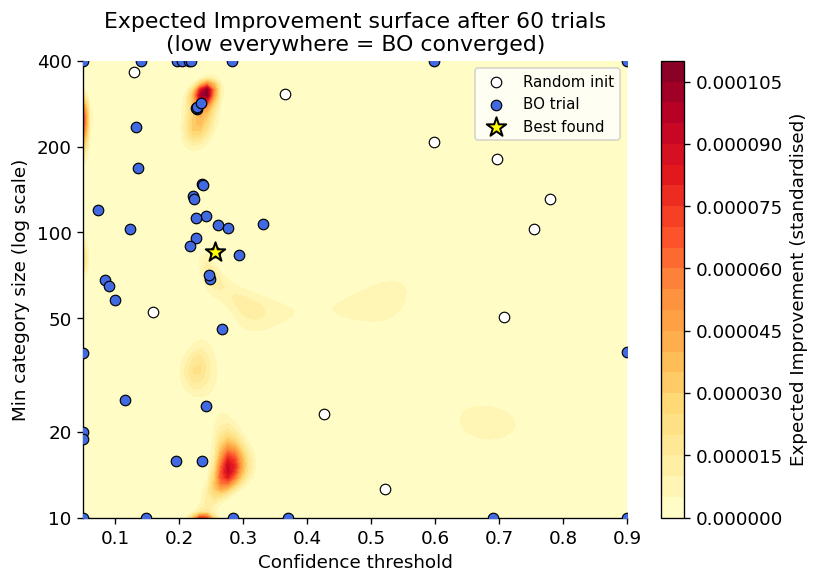

Saved: upworthy_ei_surface.png


In [6]:
# EI in normalised space with standardised y_best
y_best_std = float(y_std.max())
ei_vals = expected_improvement(X_grid_unit, gp, y_best=y_best_std, xi=0.0)

fig, ax = plt.subplots(figsize=(7, 5))
cf = ax.contourf(
    thresh_vals, log_mcs_vals, ei_vals.reshape(N_GRID, N_GRID),
    levels=25, cmap="YlOrRd"
)
fig.colorbar(cf, ax=ax, label="Expected Improvement (standardised)")
ax.scatter(X_raw[:N_INIT, 0], X_raw[:N_INIT, 1],
           c="white", edgecolors="k", s=40, lw=0.7, label="Random init", zorder=5)
ax.scatter(X_raw[N_INIT:, 0], X_raw[N_INIT:, 1],
           c="royalblue", edgecolors="k", s=40, lw=0.7, label="BO trial", zorder=5)
ax.scatter(X_raw[best_idx, 0], X_raw[best_idx, 1],
           c="yellow", edgecolors="k", s=150, lw=1.2,
           marker="*", label="Best found", zorder=6)
ax.set_xlabel("Confidence threshold")
ax.set_ylabel("Min category size (log scale)")
ax.set_yticks(log_mcs_ticks)
ax.set_yticklabels(mcs_tick_labels)
ax.set_title("Expected Improvement surface after 60 trials\n(low everywhere = BO converged)")
ax.legend(fontsize=9)
fig.tight_layout()
fig.savefig(FIGURES_DIR / "upworthy_ei_surface.png", bbox_inches="tight")
plt.show()
print("Saved: upworthy_ei_surface.png")

### Reading the EI surface

After 60 trials the EI surface is nearly flat — the GP does not see any unexplored region that is likely to beat the current best of F ≈ 1569. Any residual EI will be concentrated in high-threshold or very-low-threshold corners, which the GP has correctly identified as unpromising (low $\mu$) but uncertain (high $\sigma$). The exploration term in EI keeps a small nonzero value there, but it is too small to be actionable.

This flatness is the signal that **BO has converged**: it has sufficiently mapped the landscape and is confident the optimum has been found.

## 6  Best Configuration: What the Optimum Means

BO found the best configuration; now let's interpret it in domain terms.

**The BO-optimal pipeline:**
- Accept BART's label only when confidence ≥ **0.256** (the STAT 230A project used 0.30 by default)
- Require at least **86 headlines** per category in the ANOVA

**Why does this beat the defaults?**
- Threshold 0.256 vs 0.30: slightly more lenient, keeping ~88% of headlines labeled rather than ~79%. The extra 9% of headlines (those with BART confidence between 0.256 and 0.30) are correctly accepted — they are genuinely high-confidence enough to be informative.
- Min 86 vs 1: small groups (< 86 headlines) are excluded because their within-group variance estimates are unreliable. This reduces noise in the ANOVA.

The first code block below prints the numerical comparison. The second produces a **box plot** showing `log(CTR)` distributions across the 7 categories under the BO-optimal threshold — visually confirming that the categories have meaningfully different CTR distributions (which is what a high F-statistic means).

In [7]:
# Load the data (mirrors UpworthyBlackBox.__init__)
cats  = pd.read_csv(UPWORTHY_REPO / "data/processed/categories_raw.csv")
clean = pd.read_csv(UPWORTHY_REPO / "data/processed/confirmatory_clean.csv",
                    usecols=["headline", "log_ctr"])
df = clean.merge(cats, on="headline", how="inner")

# Best config
best_row  = bo_df.loc[bo_df["f_stat"].idxmax()]
BEST_THRESH = float(best_row["confidence_threshold"])
BEST_MINCAT = int(best_row["min_cat_size"])
BEST_F      = float(best_row["f_stat"])

print(f"Best configuration found by BO:")
print(f"  confidence_threshold = {BEST_THRESH:.3f}")
print(f"  min_cat_size         = {BEST_MINCAT}")
print(f"  F-statistic          = {BEST_F:.2f}")
print(f"  coverage             = {float(best_row['coverage']):.1%}")
print()

# Apply best config
df["category"] = df["category_raw"].where(
    df["category_confidence"] >= BEST_THRESH, "other"
)
groups_best = {
    cat: grp["log_ctr"].values
    for cat, grp in df[df["category"] != "other"].groupby("category_raw")
    if len(grp) >= BEST_MINCAT
}

# Paper default (threshold=0.30)
PAPER_THRESH = 0.30
PAPER_MINCAT = 1
groups_paper = {
    cat: grp["log_ctr"].values
    for cat, grp in df[df["category_confidence"] >= PAPER_THRESH].groupby("category_raw")
    if len(grp) >= PAPER_MINCAT
}
f_paper, _ = f_oneway(*groups_paper.values())

print(f"Paper default (threshold=0.30, min_cat=1): F = {f_paper:.2f}")
print(f"BO optimum   (threshold={BEST_THRESH:.3f}, min_cat={BEST_MINCAT}): F = {BEST_F:.2f}")
print(f"Improvement: +{(BEST_F/f_paper - 1)*100:.1f}%")

Best configuration found by BO:
  confidence_threshold = 0.256
  min_cat_size         = 86
  F-statistic          = 1568.71
  coverage             = 88.8%

Paper default (threshold=0.30, min_cat=1): F = 1447.44
BO optimum   (threshold=0.256, min_cat=86): F = 1568.71
Improvement: +8.4%


/var/folders/j3/x_9w32_14y9f51htqql7f2m80000gn/T/ipykernel_8417/1023297875.py:19: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(


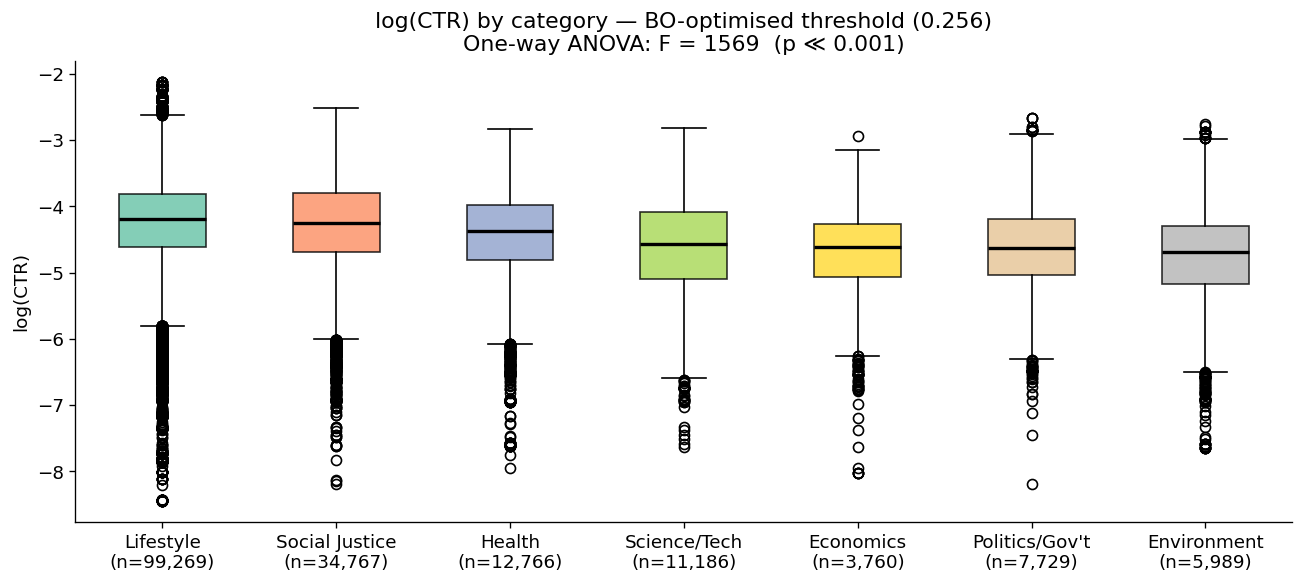

Saved: upworthy_best_config_boxplot.png


In [8]:
# Box plots: log(CTR) by category under best configuration
cat_order = sorted(groups_best, key=lambda c: np.median(groups_best[c]), reverse=True)
data_ordered = [groups_best[c] for c in cat_order]

# Shorten labels for display
label_map = {
    "politics and government":       "Politics/Gov't",
    "social justice and inequality": "Social Justice",
    "health and medicine":           "Health",
    "environment and climate":       "Environment",
    "science and technology":        "Science/Tech",
    "economics and labor":           "Economics",
    "lifestyle and culture":         "Lifestyle",
}
short_labels = [label_map.get(c, c) for c in cat_order]
sizes        = [len(groups_best[c]) for c in cat_order]

fig, ax = plt.subplots(figsize=(11, 5))
bp = ax.boxplot(
    data_ordered,
    labels=[f"{s}\n(n={n:,})" for s, n in zip(short_labels, sizes)],
    patch_artist=True,
    medianprops=dict(color="black", lw=2),
    notch=False,
)
colors = plt.cm.Set2(np.linspace(0, 1, len(cat_order)))
for patch, color in zip(bp["boxes"], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.8)

ax.set_ylabel("log(CTR)")
ax.set_title(
    f"log(CTR) by category — BO-optimised threshold ({BEST_THRESH:.3f})\n"
    f"One-way ANOVA: F = {BEST_F:.0f}  (p ≪ 0.001)"
)
fig.tight_layout()
fig.savefig(FIGURES_DIR / "upworthy_best_config_boxplot.png", bbox_inches="tight")
plt.show()
print("Saved: upworthy_best_config_boxplot.png")

### Reading the box plot

Each box shows the distribution of `log(CTR)` for headlines assigned to that category by BART (at the BO-optimal threshold). Categories are sorted from highest to lowest median CTR.

**What to notice:**
- The boxes span different ranges — some categories have systematically higher CTR than others. This is the between-group variance that drives a high F-statistic.
- The whiskers (within-group spread) are substantial, but the medians are clearly separated — the signal is real despite the noise.
- The sample size `n` below each label shows how many headlines were assigned to that category. All groups are well above the `min_cat_size=86` threshold.

**Domain interpretation:** Topic matters for click-through rate on Upworthy. Headlines about some topics (e.g., lifestyle/culture or social justice) tend to have different engagement than others (e.g., economics/labor or science/technology). This finding is consistent with the STAT 230A regression analysis. The BO-tuned threshold makes this signal cleaner by filtering out the headlines where BART was uncertain about the topic assignment.

## 7  Summary

### Key findings

| Method | Best F | vs BO |
|--------|--------|-------|
| **Bayesian Optimisation** | **1568.7** | — |
| Random search | 1514.0 | −3.6% |
| Grid search | 1435.2 | −8.5% |

### What BO found

- **Optimal threshold ≈ 0.256** — slightly more lenient than the STAT 230A paper default of 0.30
- **Optimal min\_cat\_size ≈ 86** — large enough to stabilise variance estimates, small enough to keep all 7 categories
- **Coverage ≈ 88%** — the pipeline labels most headlines, filtering only the 12% where BART was least confident

### Why the threshold matters (the F-statistic tradeoff)

| Regime | What happens | Effect on F |
|--------|-------------|-------------|
| Threshold → 0 | 100% of headlines labeled; many low-confidence (noisy) assignments | F plateaus at ~1412 (sample size helps but noise hurts) |
| Threshold ≈ 0.25 | ~88% labeled; BART's most confident assignments | **F peaks at ~1569** |
| Threshold → 0.90 | <3% labeled; tiny groups | F collapses to ~200 |

### Connection to BO theory (Lec 22–23)

- **SE kernel** modelled the smooth dependence of F on (threshold, min\_cat\_size). Small changes in threshold produce small changes in F — exactly the smoothness the SE kernel assumes.
- **Log-encoding of min\_cat\_size** ensured equal kernel distances for multiplicative changes (10→30 ≈ 100→300), matching the structure of the problem.
- **EI** correctly directed evaluations away from the low-threshold plateau (F constant, no improvement possible) and toward the threshold ≈ 0.25 peak.
- **Convergence by trial ~40**: the GP had learned enough about the landscape to stop exploring — EI was flat everywhere.

### Comparison with Experiment 1 (NCF)

| | Experiment 1 (NCF) | Experiment 2 (Upworthy) |
|---|---|---|
| Black box | Train NCF → val NDCG@10 | ANOVA on BART output → F-stat |
| Cost per trial | ~24 min (GPU) | ~15 ms (local CPU) |
| Parameter space | 5D (mixed types) | 2D (continuous) |
| BO advantage | Essential (only 15 trials affordable) | Demonstrable (fast enough to compare all methods) |

Both experiments use the identical `GaussianProcess` + `expected_improvement` + `BayesianOptimizer` implementation — only the black-box function changes. This modularity is a core design goal of the project.